# CrunchTope + rhea worked example — a flow-rate sweep on a quartz column

An end-to-end Omphalos experiment: one template, one config, ten CrunchTope runs in parallel, one figure.

**The problem.** A dilute water is injected into a 100 m column of quartz sand (`quartz_column.in`, adapted from
the CrunchTope short-course exercise `Ex2Advection/ShortCourse2react.in`). Quartz dissolves kinetically towards
equilibrium as the water advects, so how much Si the fluid picks up depends on how long it spends in the column.
We sweep the Darcy flux over three orders of magnitude, from 0.1 to 100 m yr⁻¹.

**What it demonstrates.** The *equilibration length* of reactive transport: the distance a fluid must travel
before it reaches (near-)equilibrium with the mineral it is dissolving grows linearly with flow velocity. Slow
flow → the fluid leaves saturated and the whole column is at equilibrium; fast flow → only the far end of the
column does any useful reacting.

**The workflow, in five steps:**

| Step | Tool | Artefact |
|------|------|----------|
| 1. Describe the sweep | `quartz_flow_sweep.yaml` + `quartz_column.in` | — |
| 2. Generate & run in parallel (offline) | `rhea <config> local` | `run0/ … run9/`, `results.nc` |
| 3. Record what was actually varied (offline) | `coeus/compile_inputs.py <config>` | `conditions.nc` |
| 4. Load | `xarray` | grouped datasets |
| 5. Analyse | this notebook | `quartz_flow_sweep.png` |

## 1. The experiment as written down

The config is the whole experimental design. Everything else in this notebook is downstream of it.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

style_path = Path('/Users/hjb62/Python/mpl_styles/publication.mplstyle')
if style_path.exists():
    plt.style.use(str(style_path))

HERE = Path.cwd()
CONFIG = HERE / 'quartz_flow_sweep.yaml'
TEMPLATE = HERE / 'quartz_column.in'
RESULTS = HERE / 'results.nc'
CONDITIONS = HERE / 'conditions.nc'

print(CONFIG.read_text())

# Omphalos / CrunchTope example — flow-rate sweep on a 1-D quartz column.
#
# A dilute water is injected into a 100 m column of quartz sand. Quartz
# dissolves kinetically towards equilibrium as the water advects, so the amount
# of Si the fluid picks up is set by its residence time in the column. We sweep
# the Darcy flux (FLOW / constant_flow) over three orders of magnitude and watch
# the system move from reaction-limited (fast flow, fluid leaves undersaturated)
# to transport-limited (slow flow, fluid leaves at quartz saturation).
#
# Run with rhea (from this directory, omphalos environment active):
#     rhea quartz_flow_sweep.yaml local

### Frontmatter — mandatory keys. Leave blank if not applicable.
# Paths may be relative to this directory or absolute.
template: 'quartz_column.in'
database: 'datacom.dbs'
aqueous_database:
catabolic_pathways:
restart_file:

# Max wall-clock seconds per input file. Each run here takes ~3 s.
timeout: 300

# Geochemical conditions that parameter m

The one swept entry — `flow: constant_flow` — maps onto the `FLOW` block of the template, replacing the value
token in each generated input file. Here is that block as the template leaves it:

In [2]:
lines = TEMPLATE.read_text().splitlines()
start = lines.index('FLOW')
print('\n'.join(lines[start:start + lines[start:].index('END') + 1]))

FLOW
time_units       years
distance_units   meters
constant_flow    10.0
END


## 2. Run the sweep — in the shell, before opening this notebook

The sweep is run offline; this notebook only reads what it produced. From this directory, with the `omphalos`
environment active and CrunchTope installed:

```bash
rhea quartz_flow_sweep.yaml local                 # ~5 s for all ten runs
python ../../../coeus/compile_inputs.py quartz_flow_sweep.yaml
```

`rhea` builds `run0/ … run9/`, writes one modified input file plus a copy of the database into each, farms them
out across `nodes` workers, parses every CrunchTope `.tec` output back into memory and concatenates the lot into
`results.nc` along a new `file_num` dimension. `compile_inputs.py` then reads the per-run pickles and records the
values that were actually used in `conditions.nc` — worth doing as a matter of habit, and essential for
`random_uniform` sweeps where the YAML alone cannot tell you what was run.

Two notes on the invocation:

- `rhea` is the alias `install.sh` adds for `python <repo>/rhea/main.py`. Without it, call the script directly.
- Runs are farmed out with `xargs` by default; add `-b parallel` to use GNU Parallel instead, where it works.

Everything from here needs only `xarray` + `matplotlib`, so the analysis can be done anywhere — a laptop, a
different environment, or a cluster login node with the two netCDF files copied over.

In [3]:
missing = [f.name for f in (RESULTS, CONDITIONS) if not f.exists()]
if missing:
    raise FileNotFoundError(f'{", ".join(missing)} not found — run the two commands above first.')

print(f'{RESULTS.name}:    {RESULTS.stat().st_size / 1e6:.2f} MB')
print(f'{CONDITIONS.name}: {CONDITIONS.stat().st_size / 1e3:.1f} kB')

results.nc:    0.54 MB
conditions.nc: 6.3 kB


## 3. What came back

`results.nc` is one netCDF group per CrunchTope output category. Each group carries the same
`(file_num, time, X, Y, Z)` dimensions, where `file_num` carries the run numbers that compiled successfully and
`time` holds the `spatial_profile` output times declared in the template. `conditions.nc` is indexed by the same
`file_num`, so the two files join on it.

In [4]:
import netCDF4

with netCDF4.Dataset(RESULTS) as ds:
    print('groups in results.nc:', ', '.join(ds.groups))

totcon = xr.open_dataset(RESULTS, group='totcon').squeeze(drop=True)   # total aqueous concentrations
volume = xr.open_dataset(RESULTS, group='volume').squeeze(drop=True)   # mineral volume fractions
flow = xr.open_dataset(CONDITIONS, group='flow')                       # what was actually swept

totcon

groups in results.nc: TotMineral, area, conc, porosity, rate, saturation, toperatio_aq, tortuosity, totcon, velocity, volume


<xarray.Dataset> Size: 73kB
Dimensions:     (file_num: 10, time: 3, X: 100)
Coordinates:
  * X           (X) float64 800B 0.5 1.5 2.5 3.5 4.5 ... 96.5 97.5 98.5 99.5
  * time        (time) float64 24B 200.0 1e+03 5e+03
  * file_num    (file_num) int64 80B 0 1 2 3 4 5 6 7 8 9
Data variables:
    Tracer      (file_num, time, X) float64 24kB ...
    SiO2(aq)    (file_num, time, X) float64 24kB ...
    30SiO2(aq)  (file_num, time, X) float64 24kB ...

In [5]:
# Align the swept values on the file_num labels in results.nc rather than by position: a sweep
# with a failed or timed-out run compiles fewer slices than the config declared, and only the
# labels say which run is which.
flux = flow['constant_flow'].sel(file_num=totcon['file_num'])

q = flux.values                           # Darcy flux by file_num, m/yr
C = totcon['SiO2(aq)']                    # (file_num, time, X), mol/kg
V = volume['Quartztope']                  # (file_num, time, X), m3/m3
x = C['X'].values                         # cell centres, m

flux.to_dataframe().T

file_num,0,1,2,3,4,5,6,7,8,9
constant_flow,0.1,0.25,0.5,1.0,2.5,5.0,10.0,25.0,50.0,100.0


## 4. Is the fluid at steady state?

The analysis below assumes a steady fluid profile, so check it rather than assume it. Two questions, two checks:

1. *Has the fluid stopped changing?* Compare the 200 yr and 1000 yr slices. The slowest run (0.1 m yr⁻¹, a pore
   velocity of 1 m yr⁻¹ at φ = 0.1) needs ~100 yr to flush the column, so both slices should already be steady.
2. *Has the mineral stopped changing?* A fluid steady state is not a mineral steady state: quartz is being
   consumed the whole time. The 5000 yr slice shows where that starts to bite, which is why the analysis uses the
   1000 yr slice.

In [6]:
C_EQ = float(C.max())                     # quartz solubility at 25 C, mol/kg
V_0 = float(V.isel(time=0).max())         # initial quartz volume fraction

print(f'quartz solubility C_eq       = {C_EQ:.3e} mol/kg')
print(f'max |C(1000 yr) - C(200 yr)|  = {float(abs(C.isel(time=1) - C.isel(time=0)).max()) / C_EQ:.1%} of C_eq')
print(f'max |C(5000 yr) - C(1000 yr)| = {float(abs(C.isel(time=2) - C.isel(time=1)).max()) / C_EQ:.1%} of C_eq')
print(f'largest quartz loss at 1000 yr = {1 - float(V.isel(time=1).min()) / V_0:.1%}')
print(f'largest quartz loss at 5000 yr = {1 - float(V.isel(time=2).min()) / V_0:.1%}')

T_INDEX = 1     # the 1000 yr slice

quartz solubility C_eq       = 1.096e-04 mol/kg
max |C(1000 yr) - C(200 yr)|  = 3.3% of C_eq
max |C(5000 yr) - C(1000 yr)| = 2.3% of C_eq
largest quartz loss at 1000 yr = 3.4%
largest quartz loss at 5000 yr = 16.3%


## 5. Equilibration length

Define the equilibration length $L_{95}$ as the distance from the inflow at which the fluid first reaches 95% of
quartz saturation, found by interpolating each steady-state profile (with the known inflow concentration
prepended as the value at $x = 0$).

For a first-order approach to equilibrium, a fluid parcel obeys
$$\phi \rho_w \frac{\mathrm{d}C}{\mathrm{d}t} = k A \left(1 - \frac{C}{C_{eq}}\right),$$
with an e-folding time $\tau = \phi \rho_w C_{eq} / (k A)$. Carried along at the pore velocity $q/\phi$, that
gives
$$L_{95} = \frac{q}{\phi}\,\tau \ln 20 ,$$
i.e. an equilibration length **linear in the Darcy flux, through the origin**, with a slope fixed by the rate
constant $k$ (`-rate -9.5` in `MINERALS`) and the reactive surface area $A$ (`bulk_surface_area 100` in the
condition blocks). The sweep is a direct test of that prediction — and of whether CrunchTope's
`bulk_surface_area` really means m² per m³ of bulk medium.

Runs whose $L_{95}$ falls inside two grid cells (2 m) are shown but excluded from the fit: at 1 m resolution their
equilibration length is not resolved, only bounded.

In [7]:
POROSITY = 0.10          # POROSITY: fix_porosity, m3/m3
RHO_W = 1000.0           # kg/m3, converts mol/kg to mol/m3 of water
LOG_K = -9.5             # MINERALS: Quartztope -rate, log10 mol m-2 s-1
BULK_SSA = 100.0         # CONDITION: bulk_surface_area, m2 per m3 of bulk medium
C_IN = 9.7e-7            # CONDITION boundary: inflow SiO2(aq), mol/kg
SEC_PER_YR = 365.25 * 24 * 3600

TARGET_FRAC = 0.95
MIN_CELLS = 2.0
dx = float(np.diff(x)[0])


def profile(i):
    """Steady-state dissolved Si profile for run i, with the inflow node prepended at x = 0."""
    p = C.isel(time=T_INDEX, file_num=i).values
    return np.concatenate([[0.0], x]), np.concatenate([[C_IN], p])


def equilibration_length(i):
    """Distance at which run i first reaches TARGET_FRAC of quartz saturation (NaN if it never does)."""
    xa, ca = profile(i)
    target = TARGET_FRAC * C_EQ
    if ca.max() < target:
        return np.nan
    return float(np.interp(target, ca, xa))


L = np.array([equilibration_length(i) for i in range(len(q))])
fitted = L >= MIN_CELLS * dx
grid_limited = ~fitted & ~np.isnan(L)

# Least-squares fit of L = m q through the origin.
m = float((q[fitted] * L[fitted]).sum() / (q[fitted] ** 2).sum())
r2 = float(1 - ((L[fitted] - m * q[fitted]) ** 2).sum() / ((L[fitted] - L[fitted].mean()) ** 2).sum())

# First-order kinetic prediction.
tau = POROSITY * RHO_W * C_EQ / (10 ** LOG_K * BULK_SSA)                 # seconds
m_theory = np.log(1 / (1 - TARGET_FRAC)) * tau / SEC_PER_YR / POROSITY   # m per (m/yr)

print(f'fitted slope     = {m:.3f} m per (m/yr)  (R^2 = {r2:.4f}, n = {fitted.sum()} of {len(q)} runs)')
print(f'predicted slope  = {m_theory:.3f} m per (m/yr)')
print(f'fitted / predicted = {m / m_theory:.2f}')
print(f'implied kinetic e-folding time tau = {tau / 86400:.2f} d')
print(f'excluded from the fit (L95 < {MIN_CELLS * dx:.0f} m): q = {q[grid_limited]}')

fitted slope     = 0.354 m per (m/yr)  (R^2 = 0.9977, n = 5 of 10 runs)
predicted slope  = 0.329 m per (m/yr)
fitted / predicted = 1.08
implied kinetic e-folding time tau = 4.01 d
excluded from the fit (L95 < 2 m): q = [0.1  0.25 0.5  1.   2.5 ]


**A** — steady-state dissolved Si down the column, one line per Darcy flux (log distance axis, since the fast and
slow runs equilibrate three decades apart). Slow flow saturates the fluid within the first metre; the fastest run
needs tens of metres.

**B** — equilibration length against Darcy flux, with the fit through the origin and the first-order kinetic
prediction from $k$ and $A$ alone.

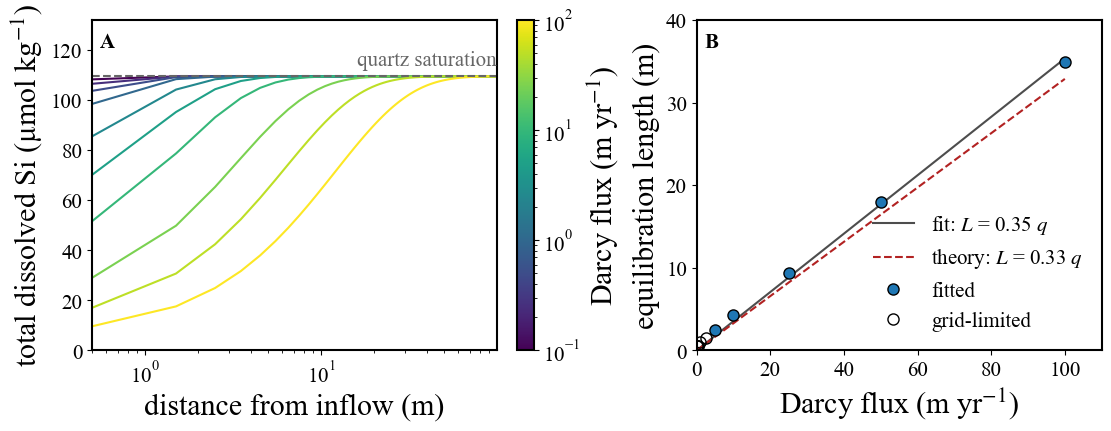

In [8]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)

norm = LogNorm(q.min(), q.max())
cmap = plt.get_cmap('viridis')

for i in range(len(q)):
    axA.plot(x, C.isel(time=T_INDEX, file_num=i).values * 1e6, color=cmap(norm(q[i])))
axA.axhline(C_EQ * 1e6, linestyle='--', color='0.4')
axA.annotate('quartz saturation', (x.max(), C_EQ * 1e6), xytext=(0, 4), textcoords='offset points',
             ha='right', va='bottom', color='0.4')
axA.set_xscale('log')
axA.set_xlim(x.min(), x.max())
axA.set_ylim(0, 132)
axA.set_xlabel('distance from inflow (m)')
axA.set_ylabel('total dissolved Si (µmol kg$^{-1}$)')
axA.text(0.02, 0.96, 'A', transform=axA.transAxes, fontweight='bold', va='top')
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axA)
cbar.set_label('Darcy flux (m yr$^{-1}$)')

qq = np.linspace(0, q.max(), 50)
axB.plot(qq, m * qq, color='0.3', label=f'fit: $L$ = {m:.2f} $q$')
axB.plot(qq, m_theory * qq, linestyle='--', color='firebrick', label=f'theory: $L$ = {m_theory:.2f} $q$')
axB.plot(q[fitted], L[fitted], marker='o', linestyle='none', label='fitted')
axB.plot(q[grid_limited], L[grid_limited], marker='o', markerfacecolor='none', linestyle='none',
         label='grid-limited')
axB.set_xlim(0, 110)
axB.set_ylim(0, 40)
axB.set_xlabel('Darcy flux (m yr$^{-1}$)')
axB.set_ylabel('equilibration length (m)')
axB.legend(frameon=False, loc='lower right')
axB.text(0.02, 0.96, 'B', transform=axB.transAxes, fontweight='bold', va='top')

fig.savefig('quartz_flow_sweep.png', dpi=300, bbox_inches='tight')

## 6. The sweep in a table

In [9]:
summary = pd.DataFrame({
    'run': np.arange(len(q)),
    'Darcy flux (m/yr)': q,
    'pore velocity (m/yr)': q / POROSITY,
    'residence time (yr)': x.max() / (q / POROSITY),
    'equilibration length (m)': np.round(L, 2),
    'outflow Si (µmol/kg)': np.round(C.isel(time=T_INDEX, X=-1).values * 1e6, 2),
    'outflow saturation (%)': np.round(100 * C.isel(time=T_INDEX, X=-1).values / C_EQ, 1),
    'quartz remaining at 5 kyr (%)': np.round(100 * V.isel(time=2).min('X').values / V_0, 1),
})
summary

,run,Darcy flux (m/yr),pore velocity (m/yr),residence time (yr),equilibration length (m),outflow Si (µmol/kg),outflow saturation (%),quartz remaining at 5 kyr (%)
0,0,0.10,1.0,99.5000,0.48,109.56,100.0,99.8
1,1,0.25,2.5,39.8000,0.49,109.56,100.0,99.5
2,2,0.50,5.0,19.9000,0.56,109.56,100.0,99.0
3,3,1.00,10.0,9.9500,1.06,109.56,100.0,98.1
4,4,2.50,25.0,3.9800,1.49,109.56,100.0,95.9
5,5,5.00,50.0,1.9900,2.46,109.56,100.0,93.3
6,6,10.00,100.0,0.9950,4.29,109.56,100.0,90.3
7,7,25.00,250.0,0.3980,9.42,109.56,100.0,86.7
8,8,50.00,500.0,0.1990,17.96,109.56,100.0,84.8
9,9,100.00,1000.0,0.0995,34.97,109.53,100.0,83.7


## 7. What the sweep says, and where to take it next

Ten runs, one swept parameter, and the equilibration length comes out linear in the Darcy flux through the origin
(R² ≈ 0.998) with a slope within ~10% of the first-order kinetic prediction built from nothing but the rate
constant, the surface area and the porosity in the template. The residual 8% and the modest curvature at the fast
end are what you would expect from the affinity term in the rate law and from 1 m grid cells; the agreement also
confirms that `bulk_surface_area` behaves as m² per m³ of bulk medium.

Natural extensions, all of them a few lines of YAML:

- **Sweep the kinetics instead.** `mineral_rates: {Quartztope&default: ['linspace', [-11, -8, 1]]}` should give
  $L_{95} \propto 1/k$ — the other half of the Damköhler-number story.
- **Two parameters at once.** Give `flow` and `mineral_rates` `custom` lists of the same length to walk a
  diagonal, or `linspace` with `repeats` to lay out a grid, and collapse both onto a single Damköhler number.
- **Random sampling.** Swap `custom` for `random_uniform` and raise `number_of_files`; `conditions.nc` is then the
  only record of what was actually run, and pairs directly with `results.nc` on `file_num`.
- **Scale out.** `rhea quartz_flow_sweep.yaml cluster` submits the same config as a SLURM array job; nothing in
  this notebook changes.

See the top-level `README.md` for the full configuration reference, the `coeus` helpers (`filter_errors`,
`quick_import`, `retrieval_run.py`) and the staged-restart machinery for spin-up chains.